In [1]:
import pickle
import cv2
import numpy as np
from matplotlib import pyplot as plt

with open('../../ETL/data/pickles/processed.pkl', 'rb') as file:
	data = pickle.load(file)
with open('../../ETL/data/pickles/patches.pkl', 'rb') as file:
	patches = pickle.load(file) 

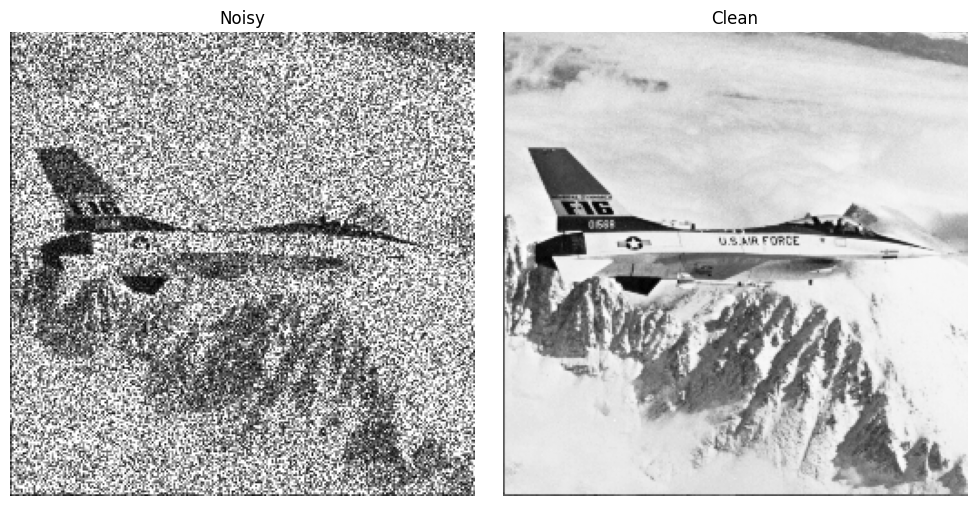

Image shape: (256, 256)
Noisy Image shape: (256, 256)
Image mean: 0.69896454
Noisy Image mean: 0.613169
Image std: 0.18350331
Noisy Image std: 0.29705673


In [5]:
i = 5
img = data['set12']['clean'][i]
noisy_img = data['set12']['noisy'][i]

# let's visualise the images with cv2, the images are in numpy array format np.float32 between 0 and 1
plt.figure(figsize=(10,5))
# Noisy
plt.subplot(1, 2, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")
# Clean
plt.subplot(1, 2, 2)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.tight_layout()
plt.show()
print("Image shape:", img.shape)
print("Noisy Image shape:", noisy_img.shape)
print("Image mean:", np.mean(img))
print("Noisy Image mean:", np.mean(noisy_img))
print("Image std:", np.std(img))
print("Noisy Image std:", np.std(noisy_img))

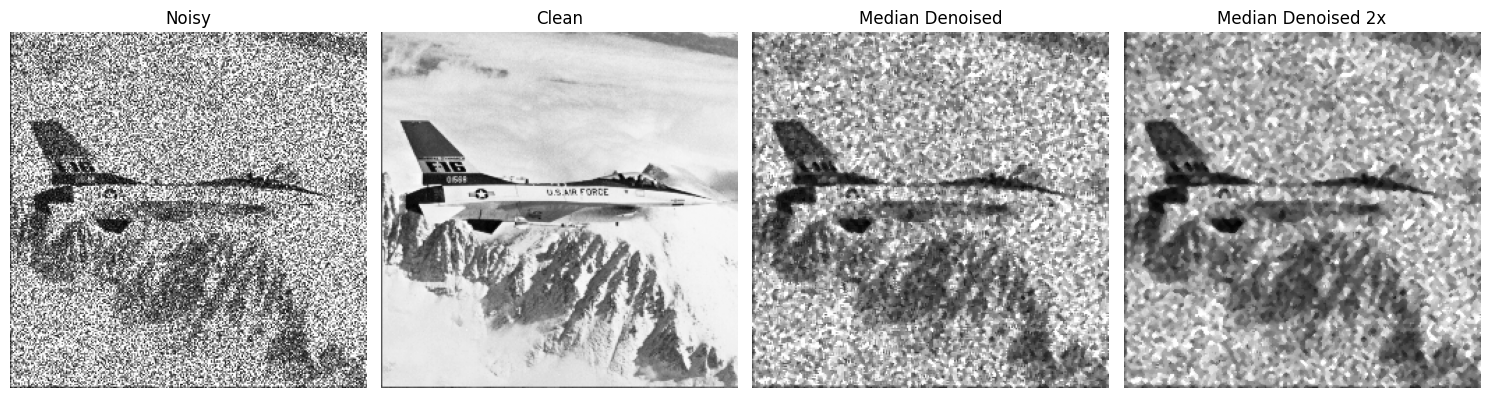

In [6]:
# conversion → uint8
noisy_8 = (noisy_img * 255).astype(np.uint8)

# filtre médian (k=3,5,7…)
k = 3
denoised_8 = cv2.medianBlur(noisy_8, k)
denoised_8_1 = cv2.medianBlur(denoised_8, k)

# retour float32 [0,1]
denoised = denoised_8.astype(np.float32) / 255.0
denoised_1 = denoised_8_1.astype(np.float32) / 255.0


plt.figure(figsize=(15,5))

# Noisy
plt.subplot(1, 4, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")

# Original (clean)
plt.subplot(1, 4, 2)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

# Denoised (median)
plt.subplot(1, 4, 3)
plt.imshow(denoised, cmap='gray')
plt.title("Median Denoised")
plt.axis("off")

# Denoised (median, second pass)
plt.subplot(1, 4, 4)
plt.imshow(denoised_1, cmap='gray')
plt.title("Median Denoised 2x")
plt.axis("off")

plt.tight_layout()
plt.show()


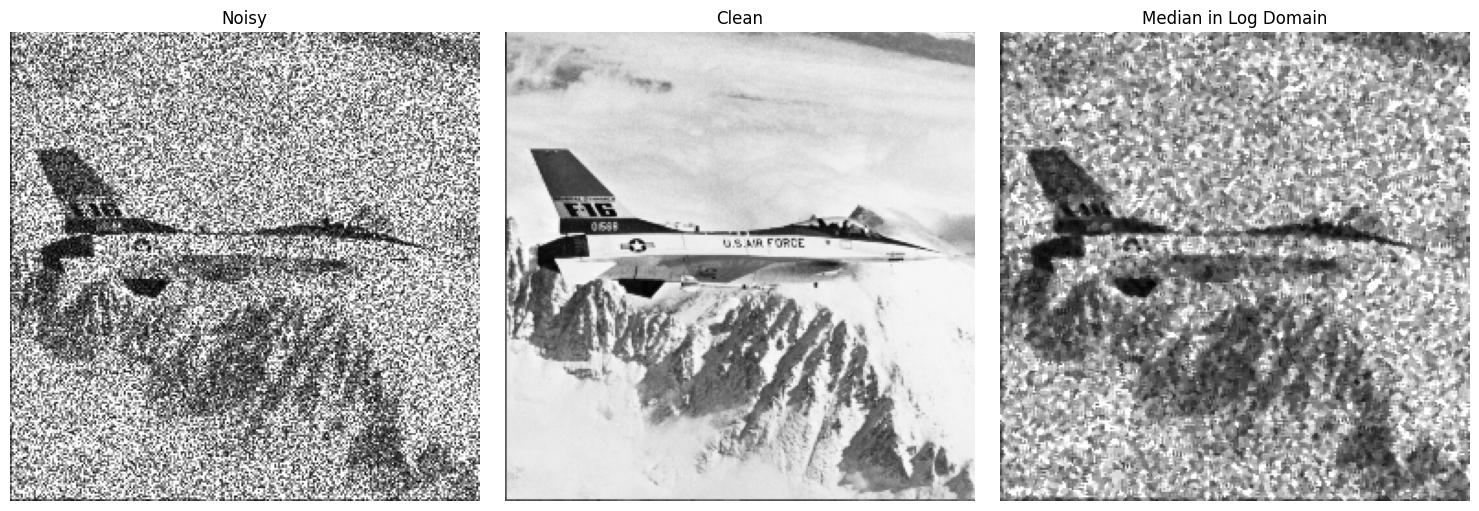

In [7]:

# Step 1: Convert to log domain (adding a small epsilon to avoid log(0))
eps = 1e-6
log_noisy = np.log(noisy_img + eps)

# Step 2: Convert to uint8 for OpenCV (scale to 0-255)
log_noisy_8 = ((log_noisy - log_noisy.min()) / (log_noisy.max() - log_noisy.min()) * 255).astype(np.uint8)

# Step 3: Apply median filter in the log domain
k = 3
log_denoised_8 = cv2.medianBlur(log_noisy_8, k)

# Step 4: Convert back to float and scale back to original log range
log_denoised = log_denoised_8.astype(np.float32) / 255 * (log_noisy.max() - log_noisy.min()) + log_noisy.min()

# Step 5: Convert back to intensity domain (exponential)
denoised_log = np.exp(log_denoised) - eps

# Now you can plot it the same way
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(denoised_log, cmap='gray')
plt.title("Median in Log Domain")
plt.axis("off")

plt.tight_layout()
plt.show()


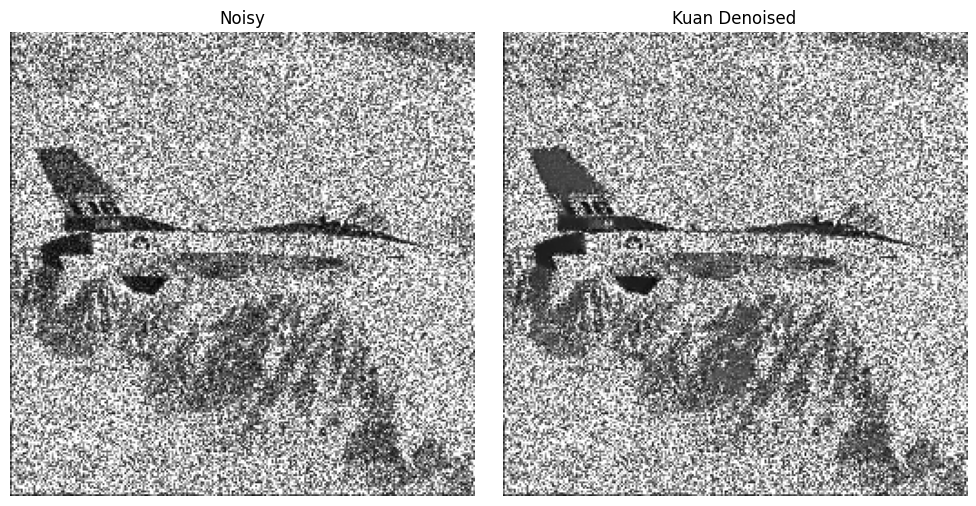

In [10]:
from skimage.restoration import denoise_nl_means
from skimage import img_as_float

# Convert the image to float (if it's not already)
noisy_img_float = img_as_float(noisy_img) 

# Apply the Kuan filter
kuan_denoised = denoise_nl_means(noisy_img_float, h=0.1, fast_mode=True)

# Plot the result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(kuan_denoised, cmap='gray')
plt.title("Kuan Denoised")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from skimage.restoration import denoise_nl_means
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import numpy as np
import matplotlib.pyplot as plt

# Now 'img' is your clean image and 'noisy_img' is your noisy image
clean = img
noisy_img = noisy_img

# Convert images to float if needed
clean = clean.astype(np.float32) / 255.0
noisy_img = noisy_img.astype(np.float32) / 255.0

# Range of h values to test
h_values = [0.05, 0.1, 0.15, 0.2, 0.25]

# Store results
results = []

for h in h_values:
    # Apply the Kuan filter (using denoise_nl_means as an example)
    denoised = denoise_nl_means(noisy_img, h=h, fast_mode=False, patch_size=5, patch_distance=3, multichannel=False)

    # Calculate PSNR and SSIM
    psnr_value = psnr(clean, denoised, data_range=1.0)
    ssim_value = ssim(clean, denoised, data_range=1.0)

    # Store the results
    results.append((h, psnr_value, ssim_value))

# Print results
for h, psnr_value, ssim_value in results:
    print(f"h={h}: PSNR={psnr_value:.2f}, SSIM={ssim_value:.4f}")

# Optional: Plot results
hs, psnrs, ssims = zip(*results)
plt.figure()
plt.plot(hs, psnrs, label='PSNR')
plt.plot(hs, ssims, label='SSIM')
plt.xlabel('h value')
plt.ylabel('Metric value')
plt.legend()
plt.show()


AttributeError: 'ellipsis' object has no attribute 'astype'

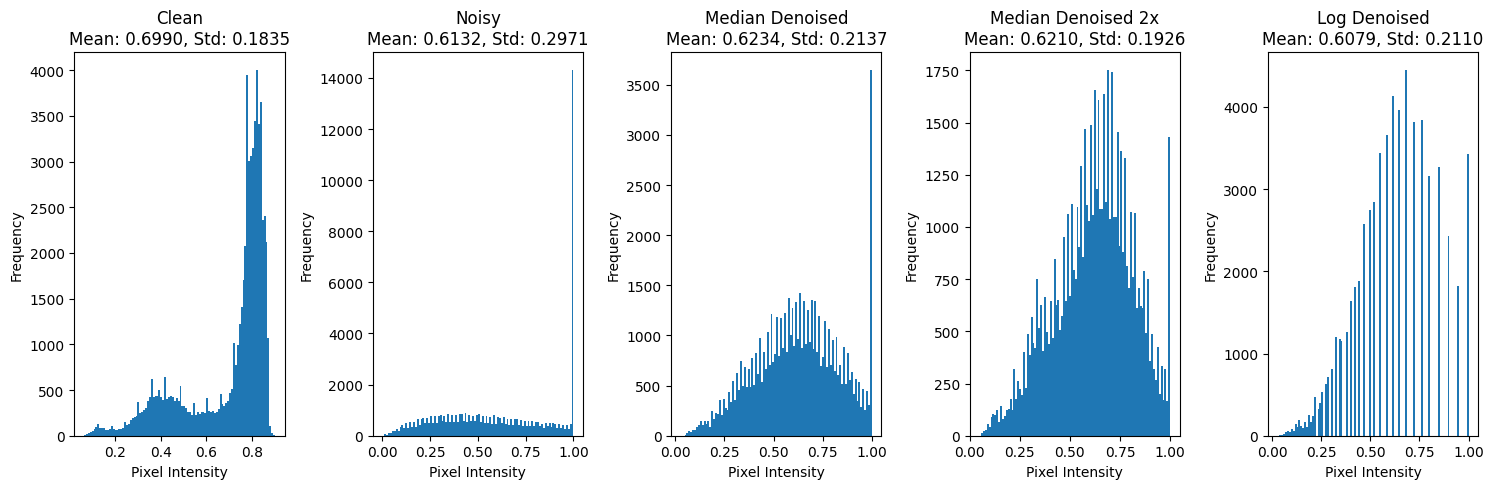

In [8]:
# let's study the mean, std and histogram of original, noisy and denoised images
def plot_image_stats(images, titles):
	plt.figure(figsize=(15,5))
	for i, img in enumerate(images):
		mean = np.mean(img)
		std = np.std(img)
		plt.subplot(1, len(images), i+1)
		plt.hist(img.ravel(), bins=100)
		plt.title(f"{titles[i]}\nMean: {mean:.4f}, Std: {std:.4f}")
		plt.xlabel("Pixel Intensity")
		plt.ylabel("Frequency")
	plt.tight_layout()
	plt.show()
plot_image_stats([img, noisy_img, denoised, denoised_1, denoised_log], ["Clean", "Noisy", "Median Denoised", "Median Denoised 2x","Log Denoised"])#!/usr/bin/env python3